<a href="https://colab.research.google.com/github/gokulgpn/remote-sensing-portfolio/blob/main/juaboso-deforestation-risk/notebooks/01_landcover_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Overview

This section introduces various landcover datasets and shows you how to use them. We will work with two different global landcover datasets [ESA WorldCover](https://esa-worldcover.org/en) and [GLAD Global Land Cover and Land Use Change](https://glad.umd.edu/dataset/GLCLUC2020). You will learn how to:


* Visualize landcover data
* Calculate areas of each landcover class
* How to reclassify and compare different datasets

### Setup

Determine our runtime environment.


In [1]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

Mounted at /content/drive
Environment: colab
Data folder: /content/drive/MyDrive/python-remote-sensing
Output folder: /content/drive/MyDrive/python-remote-sensing


If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [2]:
%%capture
if environment in ['colab', 'colab_enterprise']:
  !pip install pystac-client odc-stac rioxarray xarray-spatial \
    dask[distributed] jupyter-server-proxy planetary_computer

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [3]:
import os

import dask.array as da
import geopandas as gpd
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer as pc
import pyproj
import pystac_client
import rasterio
import rioxarray as rxr
import xarray as xr
from affine import Affine
from matplotlib import cm
from odc import stac
from odc.geo.geobox import GeoBox
from odc.stac import load
from xrspatial.classify import reclassify

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [4]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39959
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41989'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36331'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:33281 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:33281
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:46338
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43563 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43563
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:46350
INFO:distributed.scheduler:Receive client connection: Client-ca547acb-c175-11f1-9782-0242ac1c000c
INFO:distributed.core:Starting establish

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39959,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33281,Total threads: 1
Dashboard: http://127.0.0.1:42265/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:41989,


If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [5]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

https://8787-m-s-kkb-use1d1-2kwivb6q6e0rd-d.us-east1-1.prod.colab.dev


### Load Area of Interest

Read the file containing the city boundary.

In [6]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

Read the GeoJSON.

In [7]:
aoi_gdf = gpd.read_file(aoi_filepath)
aoi_gdf

,osm_id,osm_way_id,osm_version,osm_timestamp,osm_uid,osm_user,osm_changeset,other_tags,geometry
0,13004773,None,1,2021-07-21 15:31:23+00:00,9645335,mfbehrens,108373771,"""admin_level""=>""6"",""boundary""=>""administrative...","MULTIPOLYGON (((-3.1743 6.31283, -3.17385 6.31..."


Extract the geometry.

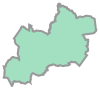

In [8]:
geometry = aoi_gdf.geometry.union_all()
geometry

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Get ESA WorldCover Data

Let's use [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/) search endpoint to look for items from the ESA WorldCover collection on Azure Blob Storage.

ESA WorldCover has data for year 2020 and 2021. We will use the 2020 data.

In [ ]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1')

search = catalog.search(
    collections=['esa-worldcover'],
    intersects=geometry,
    datetime=f'2020', # Data available only for years 2020 and 2021
)
items = search.item_collection()
items

Each STAC item has metadata containing information about the class names, legend colors and pixel values. Let's extract it so we can use it later to contruct a meaningful legend.

In [ ]:
class_list = items[0].assets['map'].extra_fields['classification:classes']
class_dict = {
    c['value']: {'description': c['description'], 'hex': c['color_hint']}
    for c in class_list
}
class_dict

{10: {'description': 'Tree cover', 'hex': '006400'},
 20: {'description': 'Shrubland', 'hex': 'FFBB22'},
 30: {'description': 'Grassland', 'hex': 'FFFF4C'},
 40: {'description': 'Cropland', 'hex': 'F096FF'},
 50: {'description': 'Built-up', 'hex': 'FA0000'},
 60: {'description': 'Bare / sparse vegetation', 'hex': 'B4B4B4'},
 70: {'description': 'Snow and ice', 'hex': 'F0F0F0'},
 80: {'description': 'Permanent water bodies', 'hex': '0064C8'},
 90: {'description': 'Herbaceous wetland', 'hex': '0096A0'},
 95: {'description': 'Mangroves', 'hex': '00CF75'},
 100: {'description': 'Moss and lichen', 'hex': 'FAE6A0'}}

Load the matching images as a XArray Dataset. Accessing data from Planetary Computer is free but requires getting a Shared Access Signature (SAS) token and sign the URLs. The `planetary_computer` Python package provides a simple mechanism for signing the URLs using `sign()` function.

In [ ]:
# Load to XArray
ds = stac.load(
    items,
    bbox=geometry.bounds, # <-- load data only for the bbox
    resolution=10,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    patch_url=pc.sign,
    groupby='solar_day',
    preserve_original_order=True
)
ds

<xarray.Dataset> Size: 193MB
Dimensions:          (y: 4939, x: 5572, time: 1)
Coordinates:
  * y                (y) float64 40kB 7.355e+05 7.355e+05 ... 6.862e+05
  * x                (x) float64 45kB 4.806e+05 4.806e+05 ... 5.363e+05
  * time             (time) datetime64[ns] 8B 2020-01-01
    spatial_ref      int32 4B 32630
Data variables:
    map              (time, y, x) uint8 28MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    input_quality.1  (time, y, x) int16 55MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    input_quality.2  (time, y, x) int16 55MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    input_quality.3  (time, y, x) int16 55MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

The landcover classification data is in the `map` variable. Select it and remove the empty `time` dimension.

In [ ]:
map_data = ds['map'].squeeze()
map_data

<xarray.DataArray 'map' (y: 4939, x: 5572)> Size: 28MB
dask.array<getitem, shape=(4939, 5572), dtype=uint8, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 40kB 7.355e+05 7.355e+05 ... 6.862e+05 6.862e+05
  * x            (x) float64 45kB 4.806e+05 4.806e+05 ... 5.363e+05 5.363e+05
    spatial_ref  int32 4B 32630
    time         datetime64[ns] 8B 2020-01-01
Attributes:
    nodata:   0

Run this computation using the local Dask cluster and load the data into memory using `.compute()`.

In [ ]:
%%time
map_data = map_data.compute()

CPU times: user 724 ms, sys: 133 ms, total: 856 ms
Wall time: 10.2 s


Clip the data to the geometry. Before we clip, we need to reproject the `aoi_gdf` to the same CRS as the data.

In [ ]:
aoi_gdf_reprojected = aoi_gdf.to_crs(map_data.rio.crs)
map_data_clipped = map_data.rio.clip(aoi_gdf_reprojected.geometry)

### Visualize the Landcover

To create a meaningful legend, we use the class names and colors from the `class_dict` created earlier.

In [ ]:
colors = ['#000000' for r in range(256)]
for key, value in class_dict.items():
    colors[int(key)] = f'#{value['hex']}'

# Set color for value 0 to transparent
colors[0] = (0, 0, 0, 0)
cmap = matplotlib.colors.ListedColormap(colors)

# Data range is 8-bit (0-255)
normalizer = matplotlib.colors.Normalize(vmin=0, vmax=255)

# Set tick labels
values = [key for key in class_dict]
boundaries = [(values[i + 1] + values[i]) / 2 for i in range(len(values) - 1)]
boundaries = [0] + boundaries + [255]
ticks = [
    (boundaries[i + 1] + boundaries[i]) / 2
    for i in range(len(boundaries) - 1)
]
tick_labels = [
    f'{value['description']} ({key})'
     for key, value in class_dict.items()
]
tick_labels

['Tree cover (10)',
 'Shrubland (20)',
 'Grassland (30)',
 'Cropland (40)',
 'Built-up (50)',
 'Bare / sparse vegetation (60)',
 'Snow and ice (70)',
 'Permanent water bodies (80)',
 'Herbaceous wetland (90)',
 'Mangroves (95)',
 'Moss and lichen (100)']

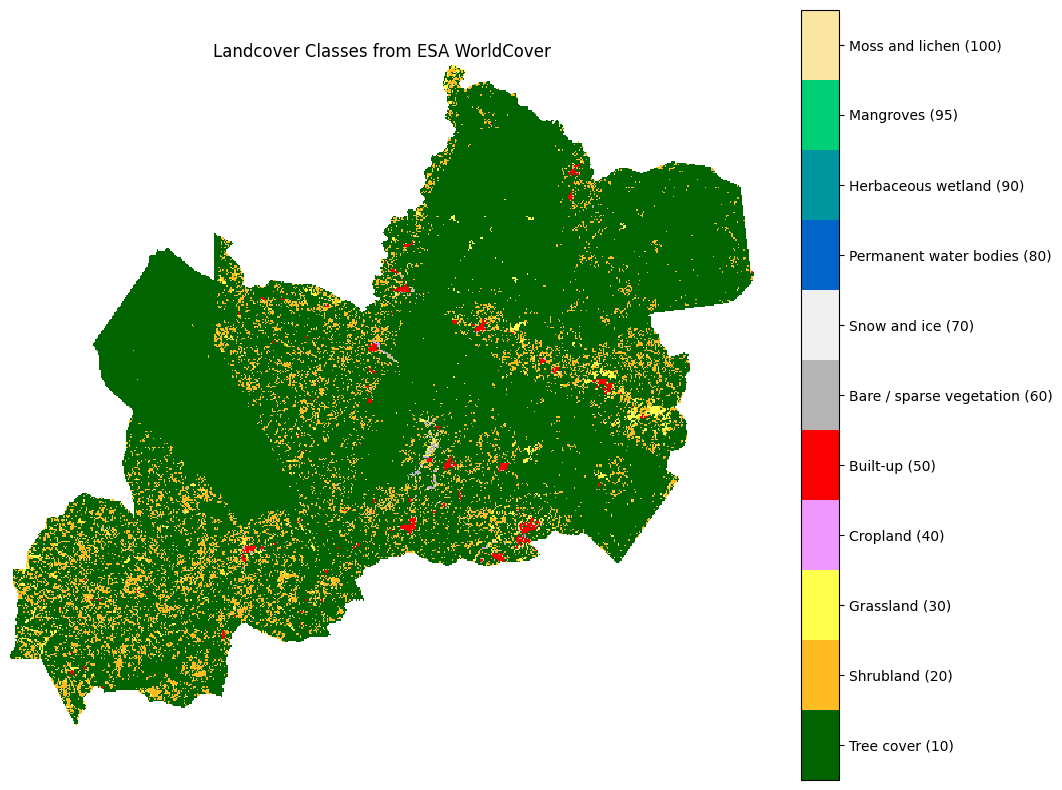

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(12, 10)

# Create a preview
map_data_preview = map_data_clipped.rio.reproject(
    map_data_clipped.rio.crs, resolution=100
)

map_data_preview.plot(
    ax=ax, cmap=cmap, norm=normalizer
)

colorbar = fig.colorbar(
    cm.ScalarMappable(norm=normalizer, cmap=cmap),
    boundaries=boundaries,
    values=values,
    cax=fig.axes[1].axes,
)
colorbar.set_ticks(ticks, labels=tick_labels)

ax.set_axis_off()
ax.set_aspect('equal')
ax.set_title('Landcover Classes from ESA WorldCover');

### Write a Paletted GeoTIFF

Let's save the clipped and reprojected data as a COG.

In [ ]:
output_file = 'esa_worldcover_original.tif'
output_path = os.path.join(output_folder, output_file)
map_data_clipped.rio.to_raster(output_path, driver='COG')
print(f'Wrote {output_path}')

Wrote /content/drive/MyDrive/python-remote-sensing/esa_worldcover_original.tif


You will notice that the output image is a single band image with pixel values such as 10, 20, ..., 90. The output image does not have the class colors applied to them. We can instead create a **paletted raster** - which can carry an embedded `colormap` that's applied automatically when the file is read. In the paletted image, the pixel values stay as their original codes (10, 20, and so on), but each one displays in its assigned color, so you get a readable image without losing the underlying data.


We first create a Color Lookup Table (LUT) mapping each pixel value to a RGBA color.

In [ ]:
color_table = {
    k: (int(v['hex'][0:2], 16), int(v['hex'][2:4], 16), int(v['hex'][4:6], 16), 255)
    for k, v in class_dict.items()
}
color_table[0] = (0, 0, 0, 0)  # nodata transparent
color_table

{10: (0, 100, 0, 255),
 20: (255, 187, 34, 255),
 30: (255, 255, 76, 255),
 40: (240, 150, 255, 255),
 50: (250, 0, 0, 255),
 60: (180, 180, 180, 255),
 70: (240, 240, 240, 255),
 80: (0, 100, 200, 255),
 90: (0, 150, 160, 255),
 95: (0, 207, 117, 255),
 100: (250, 230, 160, 255),
 0: (0, 0, 0, 0)}

At present `rioxarray` as well as `odc-geo`packages do not have built-in support for saving a colormap to a Cloud Optimized GeoTIFF (COG). We use the `rasterio` package to attach the colormap instead. Below is a helper function.

In [ ]:
def write_cog_with_colormap(data_array, output_path, color_table):
    if data_array.dtype != np.dtype('uint8'):
        raise TypeError(f'data_array must be uint8 for a color table to attach')

    # Write to a temp file, add color table, then convert to COG
    tmp_path = output_path + '.tmp.tif'
    data_array.rio.to_raster(tmp_path)

    with rasterio.open(tmp_path) as src:
        profile = src.profile.copy()
        profile['driver'] = 'COG'
        data = src.read(1)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)
            dst.write_colormap(1, color_table)

    os.remove(tmp_path)

Use the helper function to save the output as a paletted COG. Once saved, open the resulting file in GeoLibre and compare the output against a high-resolution basemap.

In [ ]:
output_file = 'esa_worldcover_colormap.tif'
output_path = os.path.join(output_folder, output_file)
write_cog_with_colormap(map_data_clipped, output_path, color_table)
print(f'Wrote {output_path}')

Wrote /content/drive/MyDrive/python-remote-sensing/esa_worldcover_colormap.tif


### Calculate Class Areas

Landcover datasets are crucial for quantifying landuse patterns. We can now calculate the area of each class within our region of interest. As our data is in a projected CRS, each pixel's area is fixed. We can count the total number of pixels for each class and multiply it by the area of a single pixel to get the area.

Let's get the underlying array of pixel values.

In [ ]:
data = map_data_clipped.values

To efficiently get the pixel counts of all unique pixel values in the data, we can use `histogram()` function provided by NumPy. The function takes an array of values and returns counts of each pixel value. We need to specify the bins to be used. Since we need counts for each class, we can use the class values as bins.

In [ ]:
# Get unique class values to define histogram bins
unique_classes = sorted(class_dict.keys())
# right edge for last bin
bins = unique_classes + [unique_classes[-1] + 1]

counts, _ = np.histogram(data, bins=bins)
counts

array([11859003,  1461977,   205974,     4615,    93434,    54474,
              0,       33,       13,        0,        0])

We now have pixel counts of each class. We multiply it by the area of each pixel to get the area. We can also filter out pixels with value 0 (nodata pixels) and counts 0 (not present in the region) to get a clean table.

In [ ]:
pixel_area_m2 = 100.0

area_df = pd.DataFrame({
    'class_value': unique_classes,
    'area_m2': counts * pixel_area_m2,
})

area_df['class_name'] = area_df['class_value'].map(
    lambda x: class_dict[x]['description'])

# Drop nodata class (0) and classes with no pixels
area_df = area_df[
    (area_df['class_value'] != 0) & (area_df['area_m2'] > 0)]

area_df

,class_value,area_m2,class_name
0,10,1.185900e+09,Tree cover
1,20,1.461977e+08,Shrubland
2,30,2.059740e+07,Grassland
3,40,4.615000e+05,Cropland
4,50,9.343400e+06,Built-up
5,60,5.447400e+06,Bare / sparse vegetation
7,80,3.300000e+03,Permanent water bodies
8,90,1.300000e+03,Herbaceous wetland


Save the results as a CSV file.

In [ ]:
output_filename = f'aoi_class_areas.csv'
output_filepath = os.path.join(output_folder, output_filename)
area_df.to_csv(output_filepath, index=False)

### Load GLAD Annual Land Cover and Land Use Dataset

Let's load another landcover dataset and learn how we can compare two different classification schemes by harmonizing them. [UMD GLAD Annual Land Cover and Land Use (GLCUC)](https://glad.umd.edu/dataset/GLCLUC2020) is a long time-series of landcover classification dataset derived from Landsat. It has detailed classification scheme with over 100 classes grouped into 7 primary classes.

The complete dataset is available on [OpenLandMap STAC Catalog](https://stac.openlandmap.org/). This is a static catalog containing many useful remote sensing dataset. As it is a static catalog, we cannot use the `search` function. You can see [Loading Data from a Static STAC Catalog](https://www.geopythontutorials.com/notebooks/stac_static_catalog.html) for a guide on how to list and load items of interest.

As we want to access just one image, it is easiest to load it directly. We access the [UMD GLAD annual land cover and land use (GLCLUC)
](https://stac.openlandmap.org/lc_glad.glcluc/collection.json?.language=en) page and obtain the URL for the COG file for 2020 landcover classification.

In [ ]:
data_url = ('https://s3.openlandmap.org/arco/'
            'lc_glad.glcluc_c_30m_s_20200101_20201231_go_epsg.4326_v20230901.tif')
glad_ds = rxr.open_rasterio(
    data_url,
    chunks={'x': 1024, 'y': 1024},
    dtype='uint8',
)
glad_ds


INFO:distributed.core:Event loop was unresponsive in Nanny for 7.45s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 7.45s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 7.45s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


<xarray.DataArray (band: 1, y: 537734, x: 1295999)> Size: 697GB
dask.array<open_rasterio-a280dc89f4d3d45309b02b1c6258a016<this-array>, shape=(1, 537734, 1295999), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 4MB 87.37 87.37 87.37 87.37 ... -62.0 -62.0 -62.0
  * x            (x) float64 10MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

This is a global raster at 30m resolution available as a single COG. We can clip and reproject the data to get the subset for our region of interest.

In [ ]:
glad_ds = glad_ds.rio.clip_box(*geometry.bounds)
glad_ds = glad_ds.odc.reproject('utm')
glad_ds

<xarray.DataArray 'reproject-4d0c3efa29024a03a3f77c64deb4a4ca' (band: 1,
                                                                y: 1612, x: 1817)> Size: 3MB
dask.array<reproject, shape=(1, 1612, 1817), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 13kB 7.356e+05 7.356e+05 ... 6.861e+05 6.861e+05
  * x            (x) float64 15kB 4.805e+05 4.806e+05 ... 5.363e+05 5.363e+05
    spatial_ref  int32 4B 32630
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

Remove the empty 'band' dimension.

In [ ]:
glad_da = glad_ds.squeeze()
glad_da

<xarray.DataArray 'reproject-4d0c3efa29024a03a3f77c64deb4a4ca' (y: 1612, x: 1817)> Size: 3MB
dask.array<getitem, shape=(1612, 1817), dtype=uint8, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 13kB 7.356e+05 7.356e+05 ... 6.861e+05 6.861e+05
  * x            (x) float64 15kB 4.805e+05 4.806e+05 ... 5.363e+05 5.363e+05
    band         int64 8B 1
    spatial_ref  int32 4B 32630
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

Run this computation using the local Dask cluster and load the data into memory using `.compute()`.

In [ ]:
%%time
glad_da = glad_da.compute()

CPU times: user 798 ms, sys: 386 ms, total: 1.18 s
Wall time: 5.82 s


In [ ]:
glad_da

<xarray.DataArray 'reproject-4d0c3efa29024a03a3f77c64deb4a4ca' (y: 1612, x: 1817)> Size: 3MB
array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 24, ..., 31,  0,  0],
       ...,
       [ 0,  0, 27, ..., 27, 30,  0],
       [ 0,  0, 27, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8)
Coordinates:
  * y            (y) float64 13kB 7.356e+05 7.356e+05 ... 6.861e+05 6.861e+05
  * x            (x) float64 15kB 4.805e+05 4.806e+05 ... 5.363e+05 5.363e+05
    band         int64 8B 1
    spatial_ref  int32 4B 32630
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

### Reclassify Pixel Values

GLAD GLCLUC encodes land cover, tree height, and change type in the range (0–254). The table below shows how value ranges map to ESA WorldCover classes.

| GLCLUC Values | GLAD Description | WorldCover Value | WorldCover Class |
|---|---|---|---|
| 0–24 | Terra Firma short vegetation | 30 | Grassland |
| 25–96 | Terra Firma tree cover | 10 | Tree cover |
| 100–124 | Wetland short vegetation | 90 | Herbaceous wetland |
| 125–196 | Wetland tree cover | 10 | Tree cover |
| 208–211 | Open surface water | 80 | Permanent water bodies |
| 240 | Short vegetation after tree loss | 30 | Grassland |
| 241–243 | Snow and ice | 70 | Snow and ice |
| 244–249 | Cropland  | 40 | Cropland |
| 250–253 | Built-up  | 50 | Built-up |
| 254 | Ocean | 80 | Permanent water bodies |


To compare both these datasets, we must harmonize the class values. We use from [`xrspatial.classify.reclassify()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.classify.reclassify.html) function from Xarray Spatial package to remap and group the pixel values to match ESA WorldCover classes.


In [ ]:
# Each bin defines the upper bound of a range (low, high]
# Gaps (97-99, 197-207, 212-239) are assigned 0 value
bins =       [ 24,  96,  99, 124, 196, 207, 211, 239, 240, 243, 249, 253, 254, 255]
new_values = [ 30,  10,   0,  90,  10,   0,  80,   0,  30,  70,  40,  50,  80,   0]

glad_da_reclass = reclassify(
    glad_da, bins=bins, new_values=new_values, name='glad_reclass'
)
glad_da_reclass

<xarray.DataArray 'glad_reclass' (y: 1612, x: 1817)> Size: 12MB
array([[30., 30., 30., ..., 30., 30., 30.],
       [30., 30., 30., ..., 30., 30., 30.],
       [30., 30., 30., ..., 10., 30., 30.],
       ...,
       [30., 30., 10., ..., 10., 10., 30.],
       [30., 30., 10., ..., 30., 30., 30.],
       [30., 30., 30., ..., 30., 30., 30.]], dtype=float32)
Coordinates:
  * y            (y) float64 13kB 7.356e+05 7.356e+05 ... 6.861e+05 6.861e+05
  * x            (x) float64 15kB 4.805e+05 4.806e+05 ... 5.363e+05 5.363e+05
    band         int64 8B 1
    spatial_ref  int32 4B 32630
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

Clip the data to geometry. Before we clip, we need to reproject the `aoi_gdf` to the same CRS as the data.

In [ ]:
aoi_gdf_reprojected = aoi_gdf.to_crs(glad_da_reclass.rio.crs)
glad_da_reclass_clipped = glad_da_reclass.rio.clip(aoi_gdf_reprojected.geometry)

The reclassify function turns the output to `float32`. We convert it back to 8-bit interger and set 0 as nodata. This is required to created a paletted output.

In [ ]:
glad_da_reclass_clipped = glad_da_reclass_clipped.fillna(0).astype('uint8')
glad_da_reclass_clipped.rio.set_nodata(0, inplace=True)
glad_da_reclass_clipped

<xarray.DataArray 'glad_reclass' (y: 1607, x: 1813)> Size: 3MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
Coordinates:
  * y            (y) float64 13kB 7.355e+05 7.355e+05 ... 6.862e+05 6.862e+05
  * x            (x) float64 15kB 4.806e+05 4.806e+05 ... 5.362e+05 5.362e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

### Compare GLCLUC with ESA WorldCover

Plot and compare both the datasets. Notice where both these datasets differ. The different in resolution (10m for ESA WorldCover vs. 30m for GLCLUC) also plays a big role in what features can be distinguished.

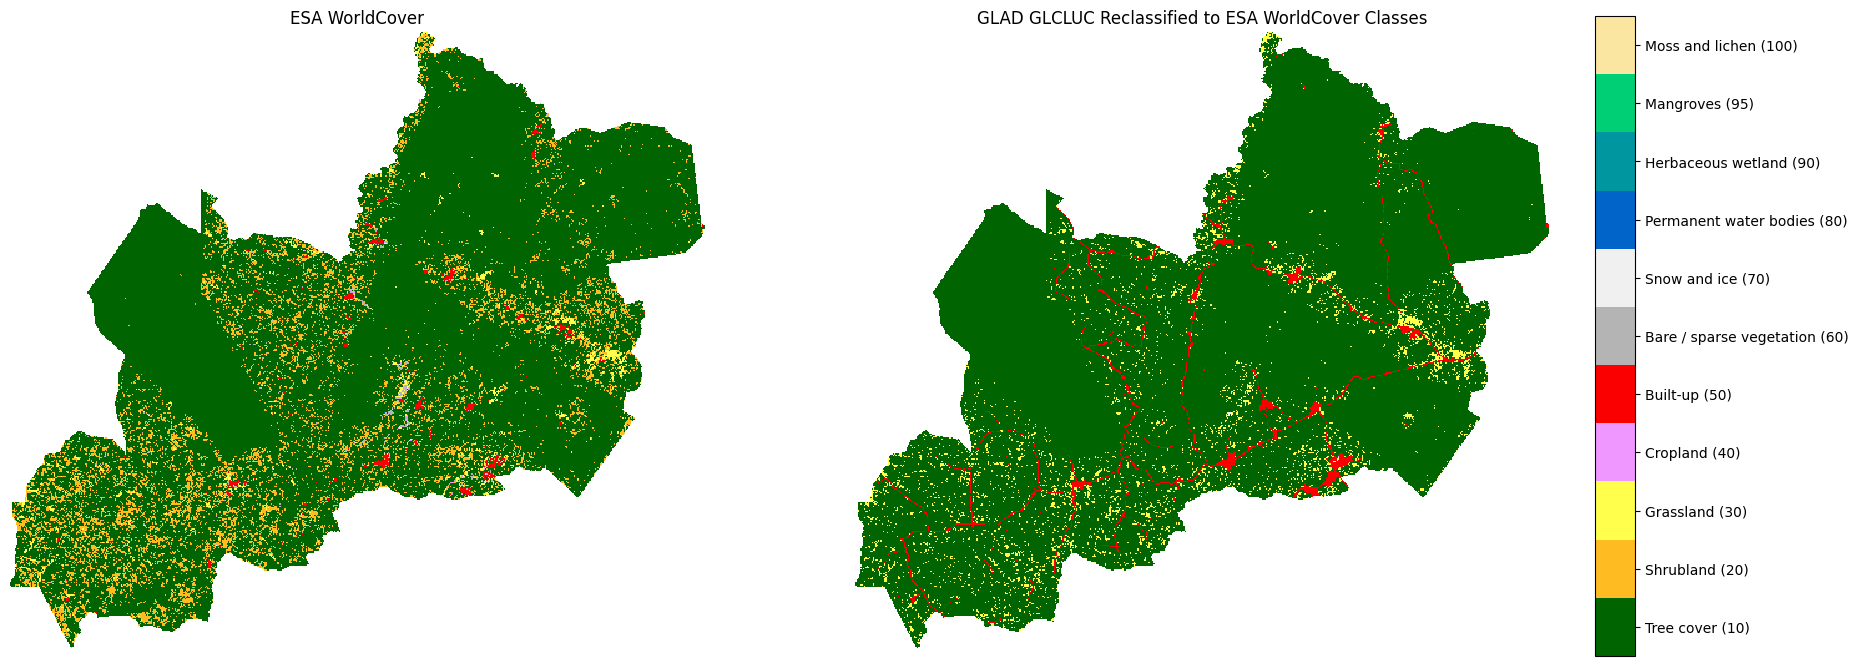

In [ ]:
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(20, 8)

map_data_preview.plot(
    ax=axes[0], cmap=cmap, norm=normalizer, add_colorbar=False)
axes[0].set_axis_off()
axes[0].set_title('ESA WorldCover')
axes[0].set_aspect('equal')

# Creat a preview
glad_data_preview = glad_da_reclass_clipped.rio.reproject(
    glad_da_reclass_clipped.rio.crs, resolution=100
)

glad_data_preview.plot(
    ax=axes[1], cmap=cmap, norm=normalizer, add_colorbar=False)
axes[1].set_axis_off()
axes[1].set_title('GLAD GLCLUC Reclassified to ESA WorldCover Classes')
axes[1].set_aspect('equal')
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])

colorbar = fig.colorbar(
    cm.ScalarMappable(norm=normalizer, cmap=cmap),
    boundaries=boundaries,
    values=values,
    cax=cbar_ax,
)
colorbar.set_ticks(ticks, labels=tick_labels)


Save the output as a palleted raster. Once saved, open the resulting COG in GeoLibre and compare the output with ESA WorldCover.

In [ ]:
output_file = 'glad_glcuc_colormap.tif'
output_path = os.path.join(output_folder, output_file)
write_cog_with_colormap(glad_da_reclass_clipped, output_path, color_table)
print(f'Wrote {output_path}')

Wrote /content/drive/MyDrive/python-remote-sensing/glad_glcuc_colormap.tif


Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()

### Exercise

Select only the pixels of *Tree Cover* (class value `10`) from the ESA WorldCover dataset to create a map of tree cover in your region.

Hint: Use the [`xr.where()`](https://docs.xarray.dev/en/stable/generated/xarray.where.html) function.